In [5]:
import os
import shutil
import random
from glob import glob
from pathlib import Path
from PIL import Image


In [6]:
os.getcwd()

'/home/dhruv/Downloads/SOLAR_PANEL'

In [7]:
src_root = "PV03"
dst_root = "output"
splits = ["train", "val", "test"]
split_ratio = [0.7, 0.15, 0.15]

random.seed(42)

# Collect all (image, mask) pairs
all_images = []
for subfolder in os.listdir(src_root):
    subfolder_path = os.path.join(src_root, subfolder)
    if os.path.isdir(subfolder_path):
        images = glob(os.path.join(subfolder_path, "*.bmp"))
        for img in images:
            if not img.endswith("_label.bmp"):
                label_img = img.replace(".bmp", "_label.bmp")
                if os.path.exists(label_img):
                    all_images.append((img, label_img))

# Shuffle and split
random.shuffle(all_images)
total = len(all_images)
train_end = int(split_ratio[0] * total)
val_end = train_end + int(split_ratio[1] * total)

splits_data = {
    "train": all_images[:train_end],
    "val": all_images[train_end:val_end],
    "test": all_images[val_end:]
}

# Create directories and convert+copy images
for split in splits:
    for sub in ["images", "masks"]:
        Path(os.path.join(dst_root, split, sub)).mkdir(parents=True, exist_ok=True)

    for img_path, mask_path in splits_data[split]:
        # Open and convert image
        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("RGB")

        # Set target paths with .jpg extension
        img_name = os.path.basename(img_path).replace(".bmp", ".jpg")
        mask_name = os.path.basename(mask_path).replace(".bmp", ".jpg")

        img.save(os.path.join(dst_root, split, "images", img_name), format="JPEG", quality=95)
        mask.save(os.path.join(dst_root, split, "masks", mask_name), format="JPEG", quality=95)

print(f"Images converted and dataset saved under '{dst_root}' with .jpg format.")


Images converted and dataset saved under 'output' with .jpg format.


In [8]:
import cv2

In [9]:
m1 = cv2.imread("/home/dhruv/Downloads/SOLAR_PANEL/output/test/masks/PV03_314602_1199237_label.jpg")
m1


array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       ...,

       [[111, 111, 111],
        [111, 111, 111],
        [111, 111, 111],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[111, 111, 111],
        [111, 111, 111],
        [111, 111, 111],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[111, 111, 111],
        [111, 111, 111],
        [111, 111, 111],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]]

In [11]:
import numpy as np
np.unique(m1)

array([  0,   1,   2,   3,   4,   5,   6,   7, 104, 105, 106, 107, 108,
       109, 110, 111, 112, 113, 114, 115, 116, 117, 119], dtype=uint8)

In [13]:
import matplotlib.pyplot as plt

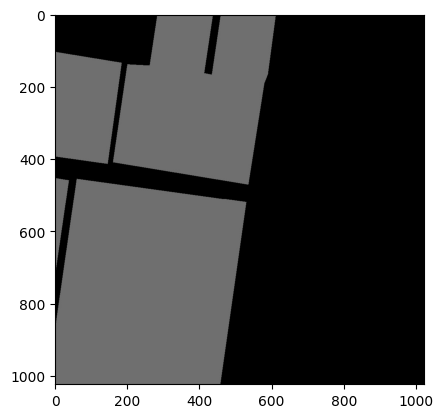

In [14]:
plt.imshow(m1)

In [15]:
m1.shape

(1024, 1024, 3)

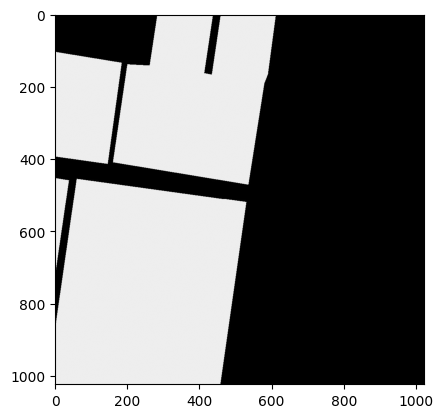

In [17]:
mask_gray = cv2.cvtColor(m1, cv2.COLOR_BGR2GRAY)

plt.imshow(mask_gray, cmap="gray")

In [21]:
import os
import cv2
from glob import glob

root_dir = "output" 

splits = ["train", "val", "test"]

mask_extensions = ["*.jpg"]

for split in splits:
    mask_dir = os.path.join(root_dir, split, "masks")

    for ext in mask_extensions:
        mask_paths = glob(os.path.join(mask_dir, ext))

        for mask_path in mask_paths:
            # Read mask in BGR
            mask_bgr = cv2.imread(mask_path)

            if mask_bgr is None:
                print(f"Warning: Could not read {mask_path}")
                continue

            # Convert to grayscale
            mask_gray = cv2.cvtColor(mask_bgr, cv2.COLOR_BGR2GRAY)

            # Overwrite original file
            cv2.imwrite(mask_path, mask_gray)
            # print(f"Converted to grayscale: {mask_path}")


In [22]:
m1 = cv2.imread("/home/dhruv/Downloads/SOLAR_PANEL/output/test/masks/PV03_314602_1199237_label.jpg")
m1.shape

(1024, 1024, 3)

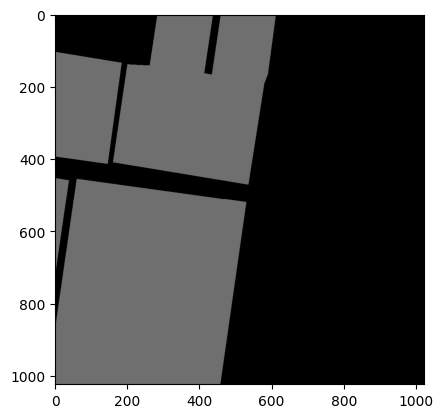

In [23]:
plt.imshow(m1)

In [24]:
np.unique(m1)

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9, 104, 105, 106,
       107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 119],
      dtype=uint8)

In [25]:
import os
import cv2
from glob import glob



In [26]:
root_dir = "output"  

splits = ["train", "val", "test"]

threshold = 10

for split in splits:
    mask_dir = os.path.join(root_dir, split, "masks")
    
    # Find all .jpg and .bmp files
    mask_paths = glob(os.path.join(mask_dir, "*.jpg"))
    
    for mask_path in mask_paths:
        # Load as grayscale
        img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # Binarize: ROI -> 255, Background -> 0
        _, binary = cv2.threshold(img, threshold, 255, cv2.THRESH_BINARY)

        cv2.imwrite(mask_path, binary)

In [3]:
import os 
os.getcwd()

'/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_SOLAR_PANEL_SEGMENTATION/SOLAR_PANEL_DATASET'

In [6]:

splits = ["train", "val", "test"]

for split in splits:
    mask_dir = os.path.join(split, "masks")
    # print(mask_dir)
    for mask_filename in os.listdir(mask_dir):
        # print(mask_filename)
        if '_label' in mask_filename:

            new_filename = mask_filename.replace('_label', '')
            
            mask_filepath = os.path.join(mask_dir, mask_filename)
            new_mask_filepath = os.path.join(mask_dir, new_filename)
            
            os.rename(mask_filepath, new_mask_filepath)